# HOTEL REVENUE ANALYSIS — COLAB NOTEBOOK

In [ ]:
"""
▶ วิธีใช้ใน Colab:
  1. Upload ไฟล์ hotel_merged_dataset.xlsx เข้า Colab ก่อน
     (ไฟล์นี้ merge hotel_Finished_dataset + dim_room_inventory แล้ว)
  2. รัน Cell นี้ครั้งเดียว แล้วค่อยรัน Cell ถัดๆ ไปตามลำดับ
"""

'\n▶ วิธีใช้ใน Colab:\n  1. Upload ไฟล์ hotel_merged_dataset.xlsx เข้า Colab ก่อน\n     (ไฟล์นี้ merge hotel_Finished_dataset + dim_room_inventory แล้ว)\n  2. รัน Cell นี้ครั้งเดียว แล้วค่อยรัน Cell ถัดๆ ไปตามลำดับ\n'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─────────────────────────────────────────────────────────────
# โหลดไฟล์ที่ Merge hotel_Finished_dataset + dim_room_inventory แล้ว
# ─────────────────────────────────────────────────────────────
df = pd.read_excel("hotel_merged_dataset_output.xlsx")

## CELL 1 : Hypothesis 1 — ขาย Promo มากเกินไปในวัน High Demand


1. 📊 กราฟ: Grouped Bar Chart — สัดส่วน Rack Rate vs Non-Rack Rate
          แยกตามวันในสัปดาห์ (เรียงจาก Mon → Sun)


2. 🔍 กราฟบอกอะไรกับเรา:
  • เปรียบเทียบสัดส่วนการขาย Rack Rate และ Non-Rack Rate
    ในแต่ละวันของสัปดาห์
  • วันศุกร์–เสาร์ (High Demand) ควรมีสัดส่วน Rack Rate สูงกว่าวันอื่น
    แต่ถ้ายังมี Non-Rack Rate ~30% แสดงว่าโรงแรมปล่อยโปรโมชัน
    มากเกินความจำเป็นในช่วงที่ควรเก็บราคาเต็ม


3. 💡 ทำไมใช้กราฟนี้:
  Grouped Bar เหมาะสมที่สุดสำหรับการเปรียบเทียบ 2 หมวดหมู่
  (Rack vs Non-Rack) ข้าม 7 วัน — ทำให้เห็นความแตกต่างของแต่ละวัน
  ได้ในมุมมองเดียว สื่อสารได้ชัดเจนกว่า Pie Chart หรือ Stacked Bar


4. 🗣️ วิธีพูดอธิบายแบบโปร:
  "กราฟนี้แสดง Rate Mix ในแต่ละวันของสัปดาห์
   จะเห็นว่าวันศุกร์และเสาร์ซึ่งเป็น Peak Demand มีสัดส่วน Non-Rack Rate
   ยังสูงถึงประมาณ X% ซึ่งหมายความว่าเรากำลังเสีย Revenue Opportunity
   เนื่องจาก Promo ที่ไม่จำเป็นในช่วงที่ Demand รองรับ Full Price ได้"


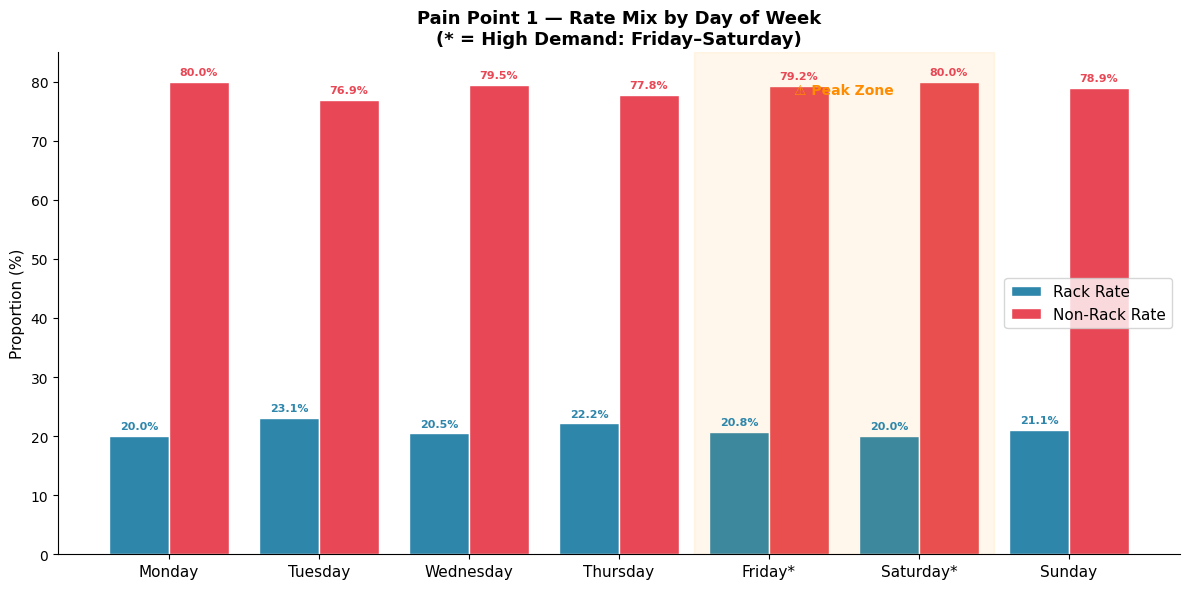

In [ ]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_th = {"Monday": "Monday", "Tuesday": "Tuesday", "Thursday": "Thursday",
          "Wednesday": "Wednesday", "Friday": "Friday*", "Saturday": "Saturday*", "Sunday": "Sunday"}

rate_mix = (
    df.groupby(["day_of_week", "is_rack"])
    .size()
    .reset_index(name="count")
)
rate_mix["day_of_week"] = pd.Categorical(rate_mix["day_of_week"], categories=day_order, ordered=True)
rate_mix = rate_mix.sort_values("day_of_week")
rate_pct = rate_mix.groupby(["day_of_week", "is_rack"], observed=False)["count"].sum().unstack(fill_value=0)
rate_pct = rate_pct.div(rate_pct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(day_order))
w = 0.4
bars1 = ax.bar(x - w/2, rate_pct[True],  w, label="Rack Rate",     color="#2E86AB", edgecolor="white")
bars2 = ax.bar(x + w/2, rate_pct[False], w, label="Non-Rack Rate", color="#E84855", edgecolor="white")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8, color="#2E86AB", fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8, color="#E84855", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([day_th[d] for d in day_order], fontsize=11)
ax.set_ylabel("Proportion (%)", fontsize=11)
ax.set_ylim(0, 85)
ax.set_title("Pain Point 1 — Rate Mix by Day of Week\n(* = High Demand: Friday–Saturday)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.axvspan(3.5, 5.5, alpha=0.08, color="orange", label="Peak Zone")
ax.text(4.5, 78, "⚠ Peak Zone", ha="center", fontsize=10, color="darkorange", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## CELL 2 : Hypothesis 2 — สัดส่วน Rack Rate โดยรวมต่ำกว่าที่ควร

1. 📊 กราฟ: Donut Chart (Pie with hole) + Bar Chart เปรียบ ADR

2. 🔍 กราฟบอกอะไรกับเรา:
  • Donut Chart แสดงสัดส่วน Rack Rate ต่อ Non-Rack Rate ทั้งหมด
    — หาก Non-Rack Rate เกิน 60% แสดงว่าโรงแรมปล่อยส่วนลดมากเกินไป
  • Bar Chart เปรียบ ADR เฉลี่ยของแต่ละ Rate Type
    — ช่วยประเมินมูลค่าที่สูญเสียต่อห้องต่อคืน

3. 💡 ทำไมใช้กราฟนี้:
  Donut เหมาะสำหรับแสดง Part-to-Whole (ส่วนแบ่งตลาด)
  ดีกว่า Pie ธรรมดาเพราะอ่านสัดส่วนได้ง่ายกว่า
  จับคู่กับ Bar Chart เพื่อเชื่อม "ปริมาณ" กับ "มูลค่า" ในสไลด์เดียว

4. 🗣️ วิธีพูดอธิบายแบบโปร:
  "จาก Donut Chart จะเห็นว่า Non-Rack Rate คิดเป็น X% ของยอดจองทั้งหมด
   เมื่อดู Bar Chart ประกอบ จะพบว่า ADR ของ Rack Rate สูงกว่า Non-Rack
   เฉลี่ย Y บาท/คืน — นั่นคือ Revenue ที่เราเสียไปโดยไม่จำเป็น
   ถ้าเราลด Non-Rack Ratio ลง 10% จะช่วยเพิ่ม RevPAR ได้ทันที"

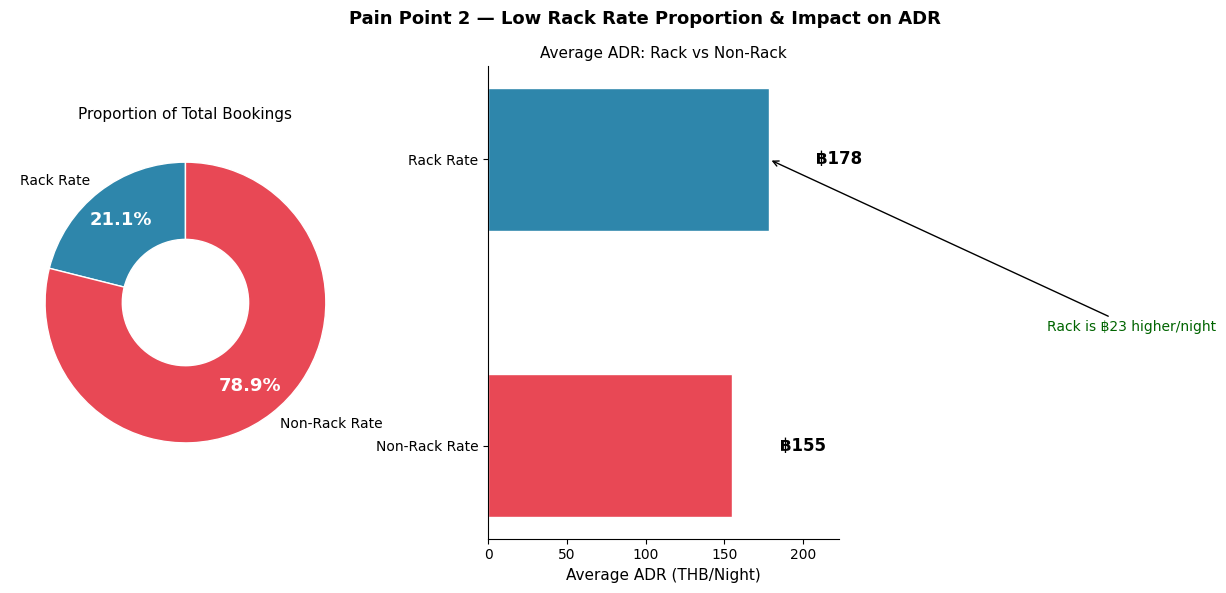

In [ ]:
rack_counts = df["is_rack"].value_counts()
rack_labels = ["Rack Rate", "Non-Rack Rate"]
rack_values = [rack_counts.get(True, 0), rack_counts.get(False, 0)]
rack_pcts   = [v / sum(rack_values) * 100 for v in rack_values]
rack_colors = ["#2E86AB", "#E84855"]

adr_by_rate = df.groupby("is_rack")["ADR"].mean()
adr_labels  = ["Non-Rack Rate", "Rack Rate"]
adr_values  = [adr_by_rate.get(False, 0), adr_by_rate.get(True, 0)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("Pain Point 2 — Low Rack Rate Proportion & Impact on ADR", fontsize=13, fontweight="bold")

# Donut
wedges, texts, autotexts = ax1.pie(
    rack_values, labels=rack_labels, colors=rack_colors,
    autopct="%1.1f%%", startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor="white"))
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight("bold"); at.set_color("white")
ax1.set_title("Proportion of Total Bookings", fontsize=11)

# Bar ADR
colors_bar = ["#E84855", "#2E86AB"]
bars = ax2.barh(adr_labels, adr_values, color=colors_bar, height=0.5, edgecolor="white")
for bar, val in zip(bars, adr_values):
    ax2.text(val + 30, bar.get_y() + bar.get_height()/2,
             f"฿{val:,.0f}", va="center", fontsize=12, fontweight="bold")
diff = adr_values[1] - adr_values[0]
ax2.annotate(f"Rack is ฿{diff:,.0f} higher/night",
             xy=(adr_values[1], 1), xytext=(adr_values[0] + 200, 0.4),
             arrowprops=dict(arrowstyle="->", color="black"), fontsize=10, color="darkgreen")
ax2.set_xlabel("Average ADR (THB/Night)", fontsize=11)
ax2.set_title("Average ADR: Rack vs Non-Rack", fontsize=11)
ax2.set_xlim(0, max(adr_values) * 1.25)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## CELL 3 : Hypothesis 3 — OTA ดึงรายได้หายไป 8.7%


1. 📊 กราฟ: Grouped Bar Chart — Gross ADR vs Net ADR แต่ละ Channel
          พร้อมเส้นแสดง Commission Rate

2. 🔍 กราฟบอกอะไรกับเรา:
  • แสดง ADR ก่อน (Gross) และหลัง (Net) หัก Commission ทุก Channel
  • ช่อง OTA เช่น Booking.com / Expedia มักมี Gross ADR สูง
    แต่พอหัก Commission ~15-18% แล้ว Net ADR อาจต่ำกว่า Direct
  • ช่วยให้เห็น "ต้นทุนที่ซ่อนอยู่" ของแต่ละ Distribution Channel

3. 💡 ทำไมใช้กราฟนี้:
  Grouped Bar + Secondary Axis (Commission %) ทำให้เห็นทั้ง "มูลค่า"
  และ "ต้นทุน" ในกราฟเดียว — เหมาะสำหรับ Revenue Manager ที่ต้อง
  เปรียบเทียบ Channel Profitability อย่างรวดเร็ว

4. 🗣️ วิธีพูดอธิบายแบบโปร:
  "กราฟนี้แสดง Channel Economics — แท่งสีน้ำเงินคือ Gross ADR
   แท่งสีส้มคือ Net ADR หลังหัก Commission
   จะเห็นว่า Booking.com มี Gross ADR สูง แต่หลังหัก Commission ที่ X%
   Net ADR ต่ำกว่า Direct Web ซึ่งหมายความว่า Direct Channel
   ให้ผลตอบแทนที่แท้จริงสูงกว่า ควรลงทุน Drive Direct Booking"


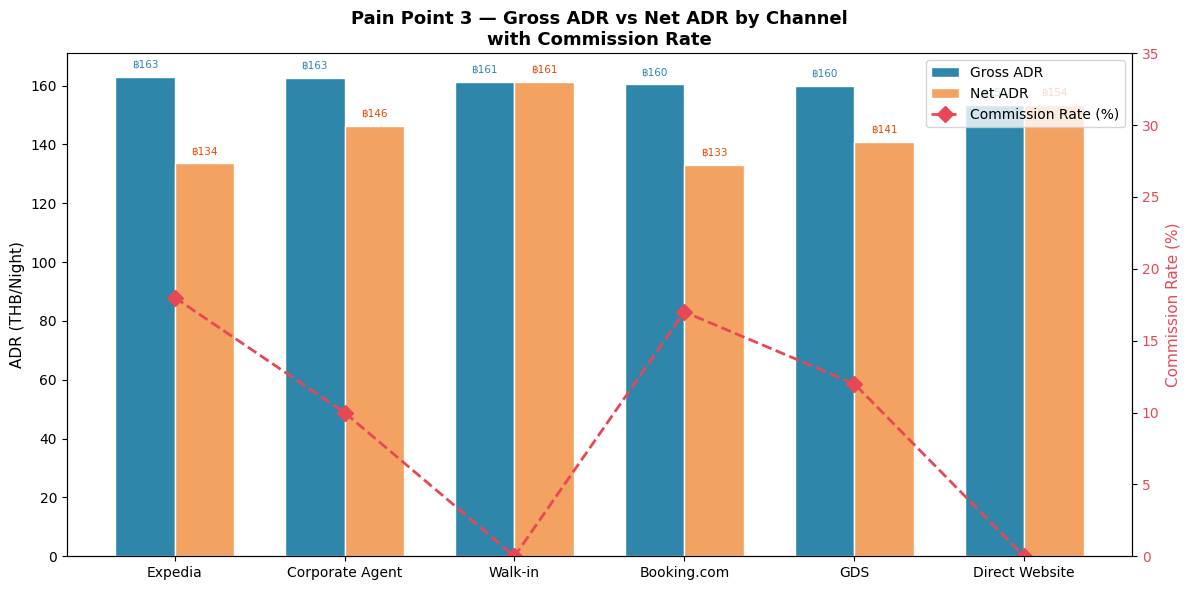

In [ ]:
ch_adr = df.groupby("channel_name").agg(
    gross_ADR=("ADR", "mean"),
    net_ADR=("net_ADR", "mean"),
    commission=("commission_rate", "mean")
).reset_index().sort_values("gross_ADR", ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

x = np.arange(len(ch_adr))
w = 0.35
b1 = ax1.bar(x - w/2, ch_adr["gross_ADR"], w, label="Gross ADR",  color="#2E86AB", edgecolor="white")
b2 = ax1.bar(x + w/2, ch_adr["net_ADR"],   w, label="Net ADR",    color="#F4A261", edgecolor="white")
line = ax2.plot(x, ch_adr["commission"] * 100, "D--", color="#E84855",
                linewidth=2, markersize=8, label="Commission Rate (%)")

for bar in b1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f"฿{bar.get_height():,.0f}", ha="center", fontsize=7.5, color="#2E86AB")
for bar in b2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f"฿{bar.get_height():,.0f}", ha="center", fontsize=7.5, color="#E04A00")

ax1.set_xticks(x)
ax1.set_xticklabels(ch_adr["channel_name"], fontsize=10)
ax1.set_ylabel("ADR (THB/Night)", fontsize=11)
ax1.set_title("Pain Point 3 — Gross ADR vs Net ADR by Channel\nwith Commission Rate", fontsize=13, fontweight="bold")
ax2.set_ylabel("Commission Rate (%)", fontsize=11, color="#E84855")
ax2.tick_params(axis="y", labelcolor="#E84855")
ax2.set_ylim(0, 35)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc="upper right")
ax1.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

## CELL 4 : Hypothesis 4 — ไม่ได้ประโยชน์จากลูกค้าจองกระชั้น

1. 📊 กราฟ: Bar Chart + Scatter Plot — ADR เฉลี่ยตามกลุ่ม Lead Time
          + แสดง Volume ประกอบ

2. 🔍 กราฟบอกอะไรกับเรา:
  • ลูกค้าที่จองล่วงหน้า 0–7 วัน (Last-Minute) ควรจ่ายราคาสูงกว่า
    เพราะห้องเหลือน้อยและ Demand สูง — แต่ถ้า ADR กลับต่ำกว่า
    แสดงว่าระบบ Pricing ยังไม่ได้ใช้ Last-Minute Premium
  • Volume ของแต่ละ Segment ช่วยบอกว่า Last-Minute มีสัดส่วนมากน้อยแค่ไหน

3. 💡 ทำไมใช้กราฟนี้:
  Bar เรียงตาม Lead Time ทำให้เห็น Pricing Curve — ควรเห็นว่า
  ยิ่งจองกระชั้นยิ่งราคาสูง (Inverse Relationship ตาม Revenue Management Theory)
  ถ้า Curve ไม่เป็นแบบนั้น คือ Pricing Opportunity ที่ยังไม่ได้ใช้

4. 🗣️ วิธีพูดอธิบายแบบโปร:
  "ตาม Revenue Management Best Practice ราคาห้องพักควรสูงขึ้น
   เมื่อ Booking Window แคบลง (Last-Minute Pricing)
   แต่จากกราฟจะเห็นว่า ADR ของลูกค้าที่จองกระชั้น (0–7 วัน)
   กลับไม่ได้สูงกว่ากลุ่มอื่น — นี่คือ Revenue Leakage
   ที่สามารถแก้ได้ด้วยการตั้ง Dynamic Rate Rule"

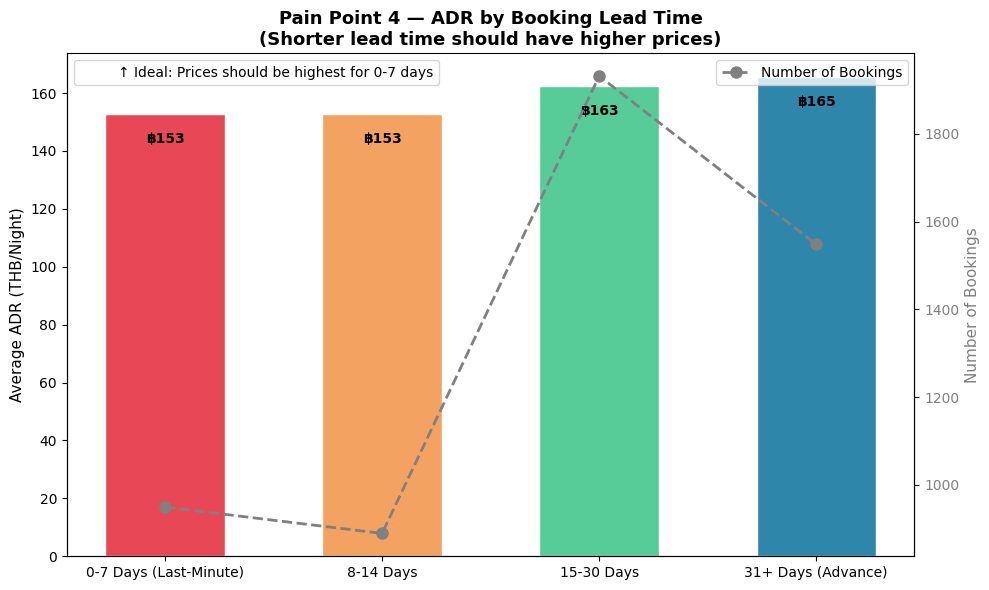

In [ ]:
lead_bin = ["0-7 Days (Last-Minute)", "8-14 Days", "15-30 Days", "31+ Days (Advance)"]

adr_by_lead = df.groupby("lead_bin").agg(
    avg_ADR=("ADR", "mean"),
    count=("ADR", "count")
).reindex(lead_bin).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

colors_lead = ["#E84855", "#F4A261", "#57CC99", "#2E86AB"]
bars = ax1.bar(adr_by_lead["lead_bin"], adr_by_lead["avg_ADR"],
               color=colors_lead, edgecolor="white", width=0.55)
ax2.plot(adr_by_lead["lead_bin"], adr_by_lead["count"], "o--",
         color="gray", linewidth=2, markersize=8, label="Number of Bookings")

for bar, row in zip(bars, adr_by_lead.itertuples()):
  ax1.text(bar.get_x() + bar.get_width()/2,
          bar.get_height() + -10,   # ลดจาก 20 → 5
          f"฿{row.avg_ADR:,.0f}",
          ha="center", fontsize=10, fontweight="bold")

ax1.set_ylabel("Average ADR (THB/Night)", fontsize=11)
ax2.set_ylabel("Number of Bookings", fontsize=11, color="gray")
ax2.tick_params(axis="y", labelcolor="gray")
ax1.set_title("Pain Point 4 — ADR by Booking Lead Time\n(Shorter lead time should have higher prices)", fontsize=13, fontweight="bold")
ax1.spines["top"].set_visible(False)

ideal_patch = mpatches.Patch(color="none", label="↑ Ideal: Prices should be highest for 0-7 days")
ax1.legend(handles=[ideal_patch], fontsize=10, loc="upper left")
ax2.legend(fontsize=10, loc="upper right")

plt.tight_layout()
plt.show()

# Findings (Insights)

1. วันหยุดขายโปรโมชันเยอะเกินไป
Weekend ที่ควรขายราคาเต็ม แต่ยังมีส่วนลดอยู่ถึง 79.6% ทั้งที่ต่างจากวันธรรมดา (78.6%) แทบไม่เลย ถ้าปิดโปรโมชันวันศุกร์–เสาร์ได้ ADR จะเพิ่มขึ้นทันที ฿23/คืน
2. ราคาเต็มขายได้แค่ 21% ของทั้งโรงแรม
ไม่ใช่แค่วันหยุด แต่ทุกวันทั้งโรงแรมปล่อยส่วนลดมากเกินไป Rack Rate มีแค่ 21.1% Non-Rack คิดเป็น 78.9% ของยอดจองทั้งหมด
3. OTA ช่วยให้มีคนจองเยอะ แต่รายได้จริงหายไป ฿175,424/ปี
OTA คิดเป็น 33.8% ของการจองทั้งหมด แต่พอหัก Commission 17.5% ออกแล้ว ได้เงินจริงต่ำกว่าจอง Direct ถึง ฿24/คืน
4. ยิ่งจองกระชั้น ยิ่งได้ราคาถูก — ซึ่งผิดปกติ
คนจองกระชั้นภายใน 7 วัน ได้ ADR ฿152.8 ถูกกว่าคนจองล่วงหน้า 31+ วัน (฿165.5) อยู่ ฿12.7/คืน ทั้งที่ห้องเหลือน้อย ราคาควรแพงขึ้น ไม่ใช่ถูกลง

# Recommendations

1. ปิดโปรโมชันวันศุกร์–เสาร์
เปิดขายเฉพาะราคาเต็ม (Rack) และ Non-Refundable แทน ไม่ต้องลด AAA หรือ Seasonal Promo ในวันที่คนอยากจองอยู่แล้ว ได้คืน ADR ฿23/คืน/ห้องทันที
2. ดึงลูกค้าให้จอง Direct แทน OTA
ทำ Best Rate Guarantee + ลงทุน Google Hotel Ads เพื่อให้คนจองตรงกับโรงแรมแทนการจองผ่าน OTA เป้าหมาย Shift 10% ภายใน 6 เดือน ประหยัด Commission ได้ ฿17,500+/ปี
3. ตั้งราคาให้แพงขึ้นเมื่อห้องเหลือน้อย
ปิดส่วนลดอัตโนมัติเมื่อ Booking Window ≤7 วัน หรือ Occupancy เกิน 70% เป้าหมายดัน ADR Last-minute จาก ฿152.8 → ฿170+ คือให้แพงกว่าคนจองล่วงหน้าด้วยซ้ำ
4. ปรับ Cancellation Policy ตามระยะเวลาที่จอง
จองไกล 30+ วัน → Non-Refundable แต่ลด 5% เป็นแรงจูงใจ
จอง 8–14 วัน → Refund ได้ 50% ถ้า Cancel ก่อน 72 ชม.
จองกระชั้น ≤7 วัน → Non-Refundable 100% เสมอ
เป้าหมายเพิ่ม Non-Refundable จาก 19.7% → 35% เพื่อให้รายได้มั่นคงขึ้น